importing libraries 

In [319]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import sklearn
from sklearn.experimental import enable_iterative_imputer  
from sklearn.linear_model import BayesianRidge
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn import metrics
import pyreadstat
import seaborn as sns
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant as ac 
import random
import warnings
warnings.filterwarnings('ignore')

load data

In [320]:
df, meta = pyreadstat.read_sav('data.sav')
df.head()

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,526301100.0,20.0,RL,141.0,31770.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,NA,0.0,5.0,2010.0,WD,Normal,215000.0
1,2.0,526350040.0,20.0,RH,80.0,11622.0,Pave,NA,Reg,Lvl,...,0.0,NA,MnPrv,NA,0.0,6.0,2010.0,WD,Normal,105000.0
2,3.0,526351010.0,20.0,RL,81.0,14267.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,Gar2,12500.0,6.0,2010.0,WD,Normal,172000.0
3,4.0,526353030.0,20.0,RL,93.0,11160.0,Pave,NA,Reg,Lvl,...,0.0,NA,NA,NA,0.0,4.0,2010.0,WD,Normal,244000.0
4,5.0,527105010.0,60.0,RL,74.0,13830.0,Pave,NA,IR1,Lvl,...,0.0,NA,MnPrv,NA,0.0,3.0,2010.0,WD,Normal,189900.0


Data Label

Distribution for LotFrontage: Linear feet of street connected to property after imputation 

In [321]:
for col, label in meta.column_names_to_labels.items():
    print(f"{col}: {label}")

Order: Observation number/ID.
PID: Parcel identification number (used for city web site review).
MSSubClass: Type of dwelling involved in the sale (a coded category).
MSZoning: General zoning classification of the sale.
LotFrontage: Linear feet of street connected to property.
LotArea: Lot size in square feet.
Street: Type of road access to property (e.g., Paved, Gravel).
Alley: Type of alley access to property.
LotShape: General shape of property (e.g., Regular, Irregular).
LandContour: Flatness of the property.
Utilities: Type of utilities available.
LotConfig: Lot configuration (e.g., Corner, Inside).
LandSlope: Slope of property (e.g., Gentle, Moderate, Severe).
Neighborhood: Physical locations within Ames city limits.
Condition1: Proximity to main road or railroad.
Condition2: Proximity to a second main road or railroad (if present).
BldgType: Type of dwelling (e.g., Single-family, Duplex).
HouseStyle: Style of dwelling (e.g., 1Story, 2Story, Split Level).
OverallQual: Overall mat

Null Count 

In [322]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

LotFrontage     490
MasVnrArea       23
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt     159
GarageCars        1
GarageArea        1
dtype: int64


Variables' unique value

In [323]:
unique_values = {col:df[col].unique() 
                 for col in df.select_dtypes(include=['object', 'category']).columns}

for col, values in unique_values.items():
    print(f"Variable: {col}")
    print(f"Values:   {values}")
    print("-" * 30)

Variable: MSZoning
Values:   ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
------------------------------
Variable: Street
Values:   ['Pave' 'Grvl']
------------------------------
Variable: Alley
Values:   ['NA' 'Pave' 'Grvl']
------------------------------
Variable: LotShape
Values:   ['IR1' 'Reg' 'IR2' 'IR3']
------------------------------
Variable: LandContour
Values:   ['Lvl' 'HLS' 'Bnk' 'Low']
------------------------------
Variable: Utilities
Values:   ['AllPub' 'NoSewr' 'NoSeWa']
------------------------------
Variable: LotConfig
Values:   ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
------------------------------
Variable: LandSlope
Values:   ['Gtl' 'Mod' 'Sev']
------------------------------
Variable: Neighborhood
Values:   ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 

number of categorical and numeric data

In [324]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
print(f"Categorical columns detected: {len(cat_cols)}")
print(f"Numerical columns detected: {len(num_cols)}")

Categorical columns detected: 43
Numerical columns detected: 39


ENCODE CATEGORICAL DATA

In [325]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan
)

df_encoded = df.copy()
if cat_cols:
    df_encoded[cat_cols] = encoder.fit_transform(df[cat_cols])

MICE IMPUTATION

In [326]:
mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=10),
    max_iter=10,
    random_state=10,
    verbose=1
)

imputed_array = mice_imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(imputed_array, columns=df.columns)

[IterativeImputer] Completing matrix with shape (2930, 82)
[IterativeImputer] Change: 764.2917403597341, scaled tolerance: 1007100.11 
[IterativeImputer] Early stopping criterion reached.


rounding values 

In [327]:
if cat_cols:
    df_imputed[cat_cols] = encoder.inverse_transform(df_imputed[cat_cols].round().astype(int))

null count after the imputation 

In [328]:
null_counts = df_imputed.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


variance check

correlation check

VIF

In [329]:
X = df_imputed.select_dtypes(include=['number'])
X_with_const = ac(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) 
                 for i in range(len(X_with_const.columns))]

vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature           VIF
17   LowQualFinSF           inf
18      GrLivArea           inf
15      @1stFlrSF           inf
16      @2ndFlrSF           inf
11     BsmtFinSF1  5.586814e+04
14    TotalBsmtSF  5.226081e+04
13      BsmtUnfSF  5.198893e+04
12     BsmtFinSF2  7.704249e+03
1           Order  7.930460e+01
38         YrSold  7.724025e+01
39      SalePrice  6.118867e+00
8       YearBuilt  5.864018e+00
29     GarageArea  5.839543e+00
28     GarageCars  5.828526e+00
27    GarageYrBlt  4.624231e+00
25   TotRmsAbvGrd  4.465149e+00
2             PID  3.776358e+00
6     OverallQual  3.773019e+00
21       FullBath  2.813025e+00
9    YearRemodAdd  2.450877e+00
23   BedroomAbvGr  2.395629e+00
22       HalfBath  2.179785e+00
19   BsmtFullBath  2.162602e+00
4     LotFrontage  1.857150e+00
3      MSSubClass  1.726864e+00
24   KitchenAbvGr  1.580021e+00
26     Fireplaces  1.568200e+00
7     OverallCond  1.543243e+00
10     MasVnrArea  1.476725e+

In [330]:
grliv_sum_array = df_imputed['@1stFlrSF'] + df_imputed['@2ndFlrSF'] + df_imputed['LowQualFinSF']
grliv_difference = df_imputed['GrLivArea'] - grliv_sum_array

bsmt_sum_array = df_imputed['BsmtFinSF1'] + df_imputed['BsmtFinSF2'] + df_imputed['BsmtUnfSF']
bsmt_difference = df_imputed['TotalBsmtSF'] - bsmt_sum_array

print(grliv_difference)
print(bsmt_difference)

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Length: 2930, dtype: float64
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Length: 2930, dtype: float64


As TotalBsmtSF is sum of BsmtFinSF1, BsmtFinSF2, BsmtUnfSF
and GrLivArea is sum of @1stFlrSF, @2ndFlrSF, LowQualFinSF.


we drop these two variable from the model 

In [331]:
cols_to_drop = [ 'Order', 'PID','GrLivArea', 'TotalBsmtSF']
df_reduced = df_imputed.drop(columns=cols_to_drop)

df_numeric_ready = pd.get_dummies(df_reduced, drop_first=True)

df_refined = df_numeric_ready.copy()

VIF After the dropping the variable

In [332]:
X = df_refined.select_dtypes(include=['number'])
X_with_const = ac(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) for i in range(len(X_with_const.columns))]
vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature       VIF
12      @1stFlrSF  6.202268
13      @2ndFlrSF  6.167740
35      SalePrice  6.099354
25     GarageArea  5.829929
24     GarageCars  5.800649
6       YearBuilt  5.725519
9      BsmtFinSF1  5.138205
23    GarageYrBlt  4.624078
21   TotRmsAbvGrd  4.449851
4     OverallQual  3.750643
11      BsmtUnfSF  3.738121
17       FullBath  2.790113
7    YearRemodAdd  2.418521
19   BedroomAbvGr  2.386757
15   BsmtFullBath  2.157575
18       HalfBath  2.151524
2     LotFrontage  1.846056
1      MSSubClass  1.724583
10     BsmtFinSF2  1.576321
20   KitchenAbvGr  1.575142
22     Fireplaces  1.567622
5     OverallCond  1.535571
8      MasVnrArea  1.461506
3         LotArea  1.352072
28  EnclosedPorch  1.240688
26     WoodDeckSF  1.231701
27    OpenPorchSF  1.223765
16   BsmtHalfBath  1.161418
30    ScreenPorch  1.093500
31       PoolArea  1.091862
14   LowQualFinSF  1.080732
32        MiscVal  1.074862
34         YrSold  1.046593
33   

Calculating the correlation matrix

In [333]:
corr_matrix = X.corr()
eigenvalues = np.linalg.eigvals(corr_matrix)

condition_number = np.sqrt(eigenvalues.max() / eigenvalues.min())

print(f"Condition Number (Kappa): {condition_number:.2f}")
if condition_number > 30:
    print("Severe multicollinearity detected (Condition Number > 30).")

Condition Number (Kappa): 9.81


split the data

In [334]:
y = df_refined['SalePrice'] 
X = df_refined.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Auto Correlation Check

Durbin-Watson statistic: 1.9593
Result: Little to no evidence of autocorrelation (values between 1.5 and 2.5 are ideal).


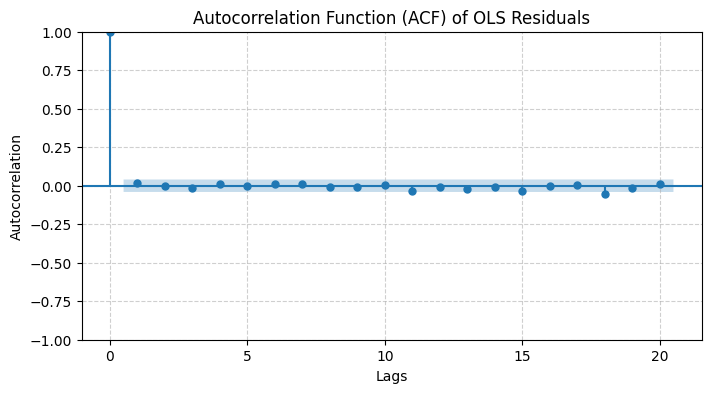

In [335]:
def analyze_and_fix_autocorrelation(X_train, y_train, max_iter=5, lag=1):

    X_train_sm = sm.add_constant(X_train)
    
    ols_model = sm.OLS(y_train, X_train_sm).fit()
    residuals = ols_model.resid
    
    dw_stat = durbin_watson(residuals)
    print(f"Durbin-Watson statistic: {dw_stat:.4f}")
    if dw_stat < 1.5:
        print("Result: Strong evidence of POSITIVE autocorrelation.")
    elif dw_stat > 2.5:
        print("Result: Strong evidence of NEGATIVE autocorrelation.")
    else:
        print("Result: Little to no evidence of autocorrelation (values between 1.5 and 2.5 are ideal).")
        
    # Plot Autocorrelation Function (ACF)
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_acf(residuals, lags=20, ax=ax, alpha=0.05)
    plt.title("Autocorrelation Function (ACF) of OLS Residuals")
    plt.xlabel("Lags")
    plt.ylabel("Autocorrelation")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return ols_model

analyze_and_fix_autocorrelation(X_train_scaled, y_train)

Ridge Trace graph

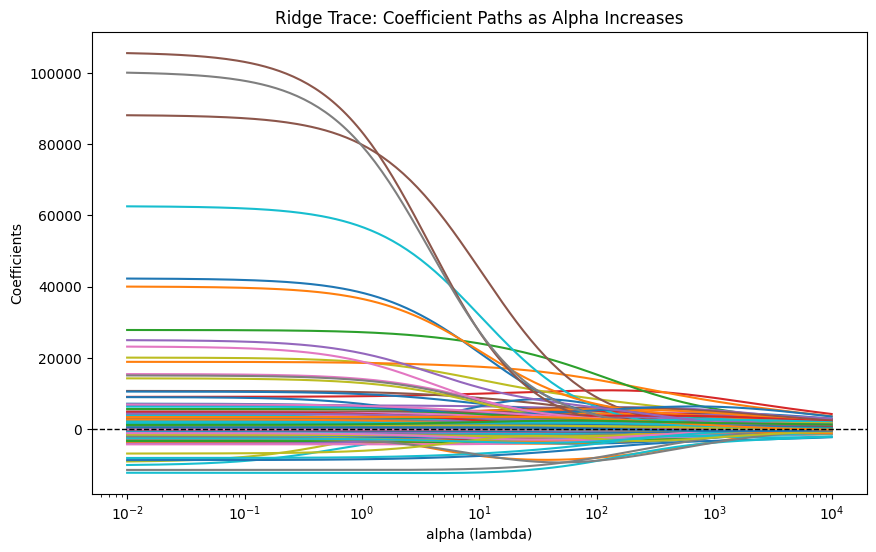

In [336]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

alphas = np.logspace(-2, 4, 200)
coefs = []

for a in alphas:
    ridge_trace = Ridge(alpha=a)
    ridge_trace.fit(X_train_scaled, y_train)
    coefs.append(ridge_trace.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha (lambda)')
plt.ylabel('Coefficients')
plt.title('Ridge Trace: Coefficient Paths as Alpha Increases')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axis('tight')
plt.show()

In [337]:
ridge = Ridge(alpha=0.6)
ridge.fit(X_train_scaled, y_train)

Ridge(alpha=0.6)

In [338]:
alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

optimal_lambda = lasso_cv.alpha_
print(f"The optimal lambda is: {optimal_lambda}")

lasso = Lasso(alpha=optimal_lambda, max_iter=100000000)
lasso.fit(X_train_scaled, y_train)


The optimal lambda is: 10.0


Lasso(alpha=np.float64(10.0), max_iter=100000000)

In [339]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net1 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net1.fit(X_train_scaled, y_train)

Optimal Alpha: 3.5111917342151275
Optimal L1 Ratio: 0.95


ElasticNet(alpha=np.float64(3.5111917342151275), l1_ratio=np.float64(0.95))

In [340]:
pcr = make_pipeline(PCA(n_components=0.95), LinearRegression())
pcr.fit(X_train_scaled, y_train)

Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('linearregression', LinearRegression())])

In [341]:
def evaluate(model, name):
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, preds))
    r2 = metrics.r2_score(y_test, preds)
    print(f"{name:20s} | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

print("--- Model Performance Comparison ---")
evaluate(ols, "Standard OLS")
evaluate(ridge, "Ridge Regression")
evaluate(lasso, "LASSO Regression")
evaluate(elastic_net1, "Elastic Net")
evaluate(pcr, "PCR (95% variance)")

--- Model Performance Comparison ---
Standard OLS         | RMSE: $35,158.48 | R2: 0.8458
Ridge Regression     | RMSE: $33,585.91 | R2: 0.8593
LASSO Regression     | RMSE: $34,252.65 | R2: 0.8537
Elastic Net          | RMSE: $30,150.89 | R2: 0.8866
PCR (95% variance)   | RMSE: $31,633.41 | R2: 0.8752


extracting the specific features that elastic net deemed most important

In [342]:
en_coefs = elastic_net1.coef_

# 3. Create the DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': en_coefs
})

# 4. Filter for features that are NOT zero
non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

# 5. Sort by absolute importance
non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 283
Features kept by Elastic Net (non-zero): 280

--- Top 20 Most Important Features ---
             Feature  Coefficient
         OverallQual 10199.635377
           @1stFlrSF 10040.113351
           @2ndFlrSF  8525.475156
         BsmtQual_Ex  6242.680672
          BsmtFinSF1  6034.823331
           PoolQC_Gd -5991.924023
Neighborhood_NoRidge  5903.899756
Neighborhood_NridgHt  5675.556464
             MiscVal -5573.082798
      KitchenQual_TA -5334.086503
Neighborhood_StoneBr  5195.739030
            FullBath  4569.789277
      KitchenQual_Gd -4372.858747
    RoofMatl_WdShngl  4312.593581
          GarageCars  4309.477519
         OverallCond  4305.388781
        TotRmsAbvGrd  4088.699131
          Fireplaces  3911.469072
          MasVnrArea  3899.712149
        ExterQual_TA -3843.100676


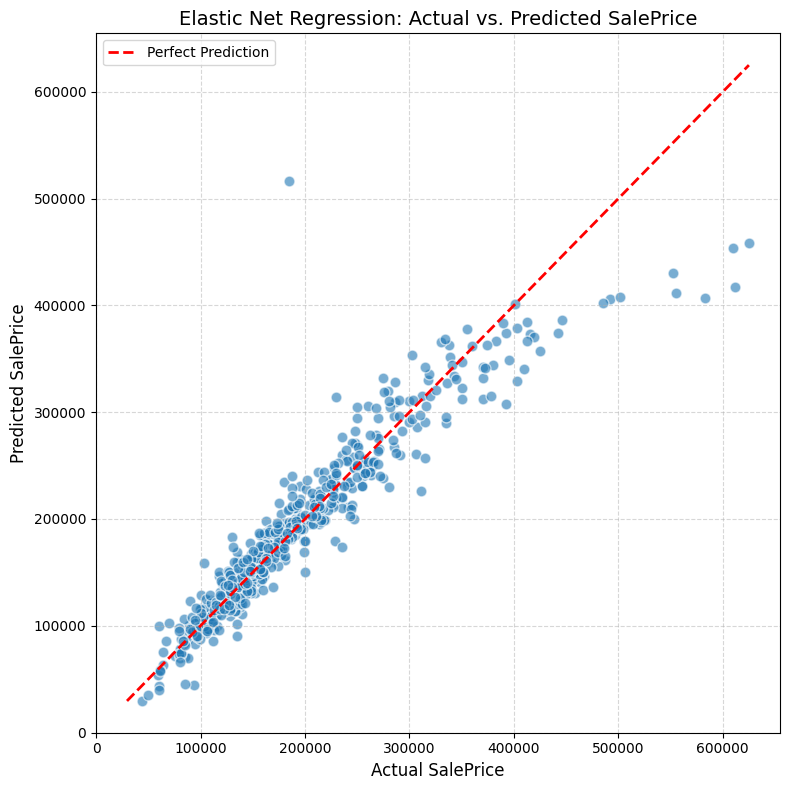

In [343]:
elastic_net_pred1 = elastic_net1.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, elastic_net_pred1, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test.min(), elastic_net_pred1.min())
max_val = max(y_test.max(), elastic_net_pred1.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

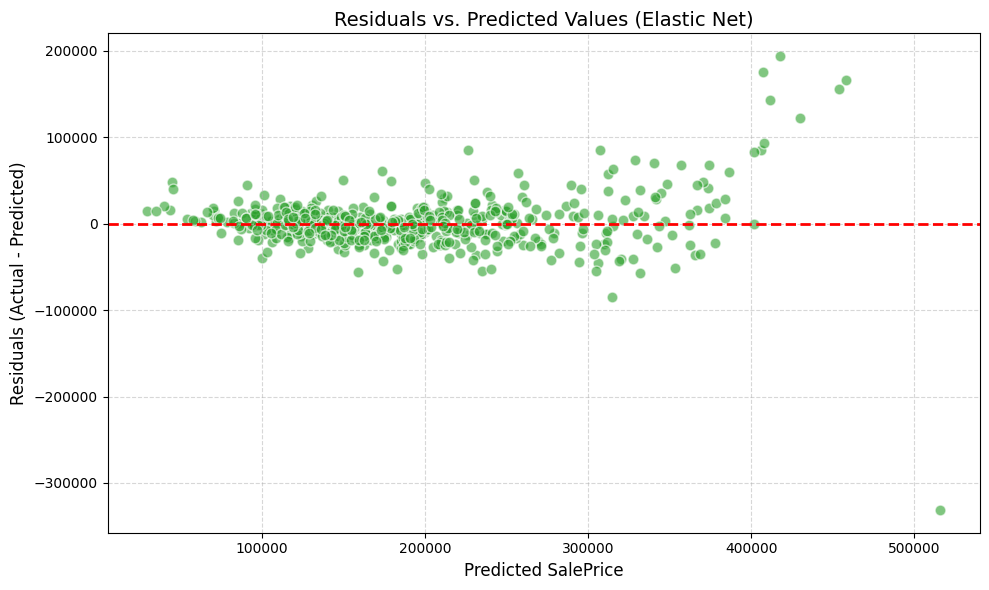

In [344]:
residuals1 = y_test - elastic_net_pred1

plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred1, residuals1, alpha=0.6, color='#2ca02c', edgecolors='w', s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [345]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

press_test_proxy = np.sum(residuals1**2)

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(elastic_net1, X_train, y_train, cv=loo)
press_statistic = np.sum((y_train - y_pred_loo)**2)

print(f"PRESS Statistic: {press_statistic}")

PRESS Statistic: 2358222758505.922


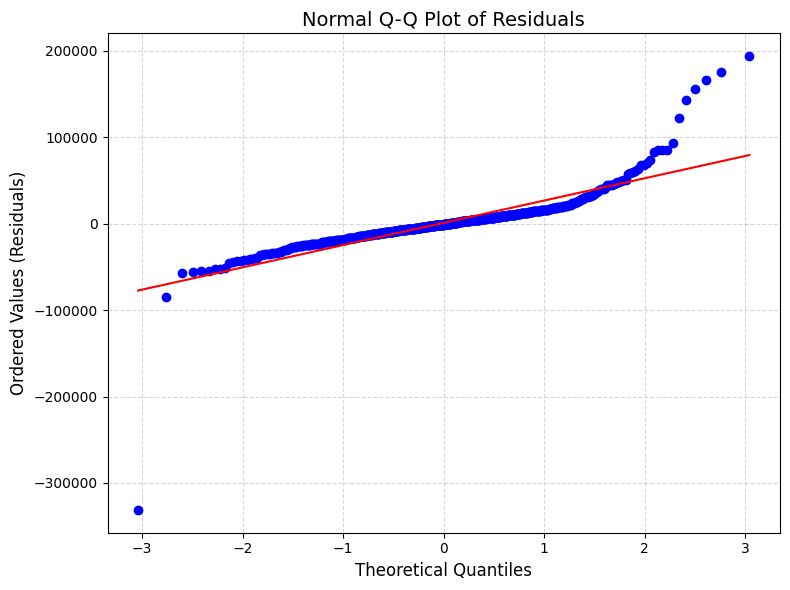

In [346]:
plt.figure(figsize=(8, 6))

# 2. Generate the Q-Q plot
# 'dist="norm"' compares your residuals against a normal distribution
stats.probplot(residuals1, dist="norm", plot=plt)

# 3. Customizing the plot
plt.title('Normal Q-Q Plot of Residuals', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [347]:
from sklearn.preprocessing import PowerTransformer
y_train_bc, lam = boxcox(y_train)
y_test_bc = boxcox(y_test, lmbda=lam)
print(f"Optimal Box-Cox Lambda: {lam:.4f}")
pt = PowerTransformer(method='yeo-johnson')

X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)


Optimal Box-Cox Lambda: 0.0443


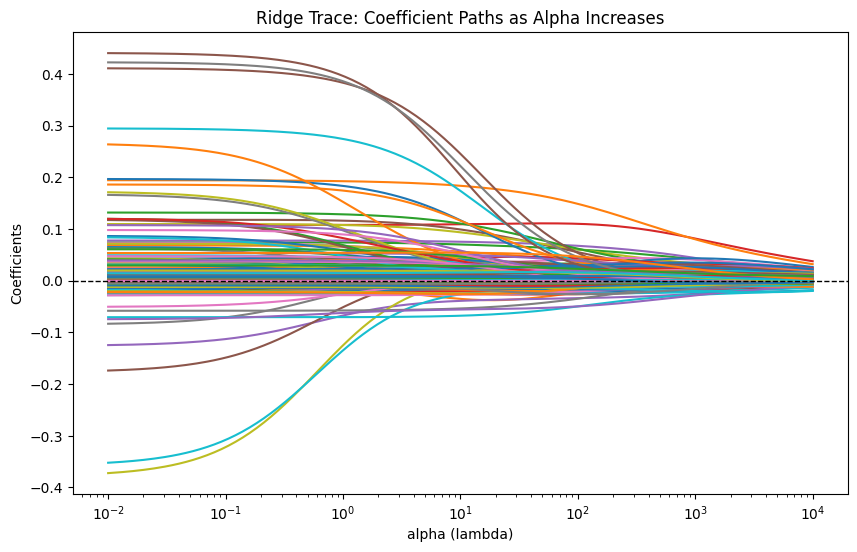

In [348]:
ols = LinearRegression()
ols.fit(X_train_transformed, y_train_bc)

alphas = np.logspace(-2, 4, 200)
coefs = []

for a in alphas:
    ridge_trace = Ridge(alpha=a)
    ridge_trace.fit(X_train_transformed, y_train_bc)
    coefs.append(ridge_trace.coef_)

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha (lambda)')
plt.ylabel('Coefficients')
plt.title('Ridge Trace: Coefficient Paths as Alpha Increases')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axis('tight')
plt.show()

In [349]:
ridge = Ridge(alpha=0.5)
ridge.fit(X_train_transformed, y_train_bc)

Ridge(alpha=0.5)

In [350]:
alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_transformed, y_train_bc)

optimal_lambda = lasso_cv.alpha_
print(f"The optimal lambda is: {optimal_lambda}")

lasso = Lasso(alpha=optimal_lambda, max_iter=10000)
lasso.fit(X_train_transformed, y_train_bc)


The optimal lambda is: 0.004132012400115334


Lasso(alpha=np.float64(0.004132012400115334), max_iter=10000)

In [351]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_transformed, y_train_bc)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net2 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net2.fit(X_train_transformed, y_train_bc)

Optimal Alpha: 0.004132012400115334
Optimal L1 Ratio: 0.95


ElasticNet(alpha=np.float64(0.004132012400115334), l1_ratio=np.float64(0.95))

In [352]:
pcr = make_pipeline(PCA(n_components=0.95), LinearRegression())
pcr.fit(X_train_transformed, y_train_bc)

Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('linearregression', LinearRegression())])

In [353]:
def evaluate(model, name):
    preds = model.predict(X_test_transformed)
    rmse = np.sqrt(metrics.mean_squared_error(y_test_bc, preds))
    r2 = metrics.r2_score(y_test_bc, preds)
    print(f"{name:20s} | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

print("--- Model Performance Comparison ---")
evaluate(ols, "Standard OLS")
evaluate(ridge, "Ridge Regression")
evaluate(lasso, "LASSO Regression")
evaluate(elastic_net2, "Elastic Net")
evaluate(pcr, "PCR (95% variance)")

--- Model Performance Comparison ---
Standard OLS         | RMSE: $0.25 | R2: 0.8854
Ridge Regression     | RMSE: $0.24 | R2: 0.8948
LASSO Regression     | RMSE: $0.20 | R2: 0.9238
Elastic Net          | RMSE: $0.20 | R2: 0.9239
PCR (95% variance)   | RMSE: $0.22 | R2: 0.9083


In [354]:
en_coefs = elastic_net2.coef_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': en_coefs
})

non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 283
Features kept by Elastic Net (non-zero): 140

--- Top 20 Most Important Features ---
             Feature  Coefficient
           @1stFlrSF     0.176067
         OverallQual     0.144548
           @2ndFlrSF     0.096772
           YearBuilt     0.083652
         OverallCond     0.073198
             LotArea     0.065730
          GarageCars     0.052635
          BsmtFinSF1     0.051264
      Functional_Sal    -0.048503
            FullBath     0.035935
SaleCondition_Normal     0.034059
         BsmtQual_Ex     0.033859
Neighborhood_NridgHt     0.032671
          Fireplaces     0.032419
Neighborhood_Crawfor     0.031392
     BsmtExposure_Gd     0.028756
Neighborhood_NoRidge     0.028750
    MSZoning_C (all)    -0.026841
        CentralAir_Y     0.025712
     Condition1_Norm     0.025360


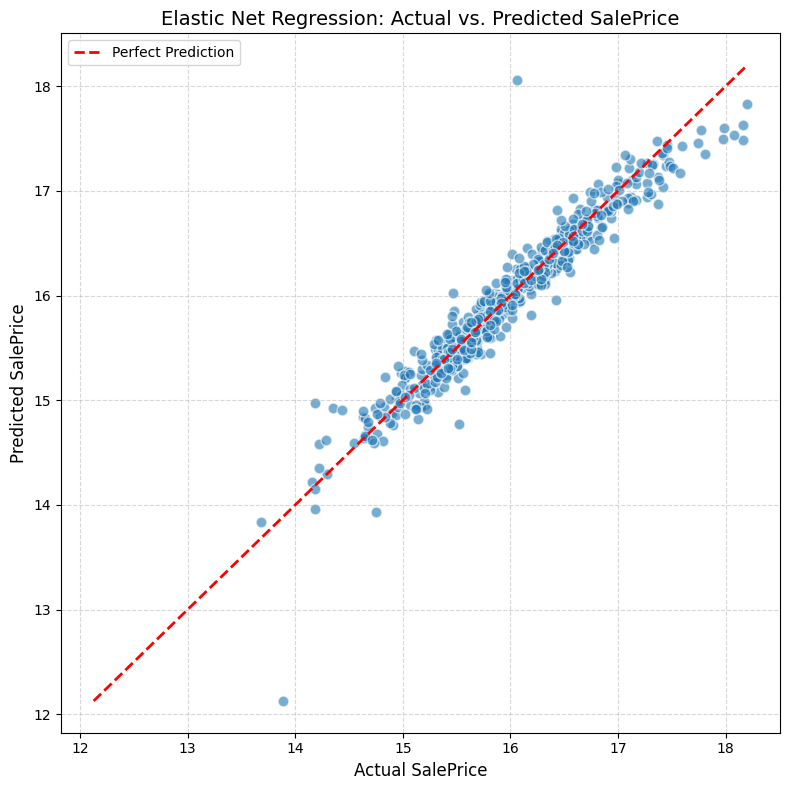

In [355]:
elastic_net_pred_transform2 = elastic_net2.predict(X_test_transformed)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_bc, elastic_net_pred_transform2, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test_bc.min(), elastic_net_pred_transform2.min())
max_val = max(y_test_bc.max(), elastic_net_pred_transform2.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

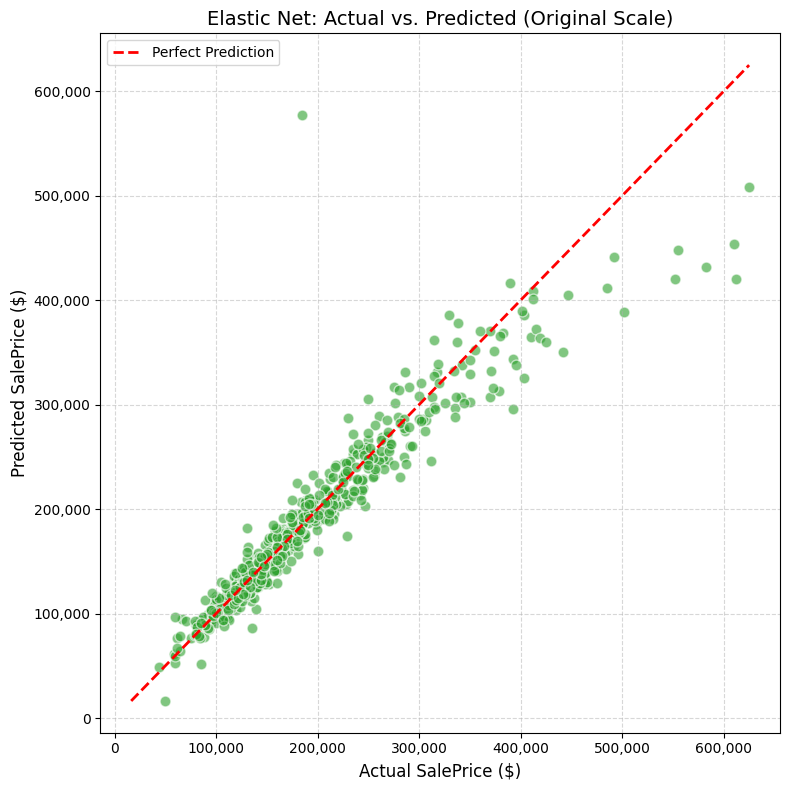

In [356]:
from scipy.special import inv_boxcox

y_test 
elastic_net_pred_original = inv_boxcox(elastic_net_pred_transform2, lam)

# 2. Plotting the original scale
plt.figure(figsize=(8, 8))
plt.scatter(y_test, elastic_net_pred_original, alpha=0.6, color='#2ca02c', edgecolors='w', s=60)

# Reference line for perfect prediction
min_val_orig = min(y_test.min(), elastic_net_pred_original.min())
max_val_orig = max(y_test.max(), elastic_net_pred_original.max())
plt.plot([min_val_orig, max_val_orig], [min_val_orig, max_val_orig], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net: Actual vs. Predicted (Original Scale)', fontsize=14)
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Formatting tick labels to be more readable (e.g., thousands)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

In [357]:
from sklearn.metrics import r2_score


r2_transformed = r2_score(y_test_bc, elastic_net_pred_transform2)
r2_original = r2_score(y_test, elastic_net_pred_original)

print(f"R^2 Score (Transformed Scale): {r2_transformed:.4f}")
print(f"R^2 Score (Original Scale):    {r2_original:.4f}")

R^2 Score (Transformed Scale): 0.9239
R^2 Score (Original Scale):    0.8936


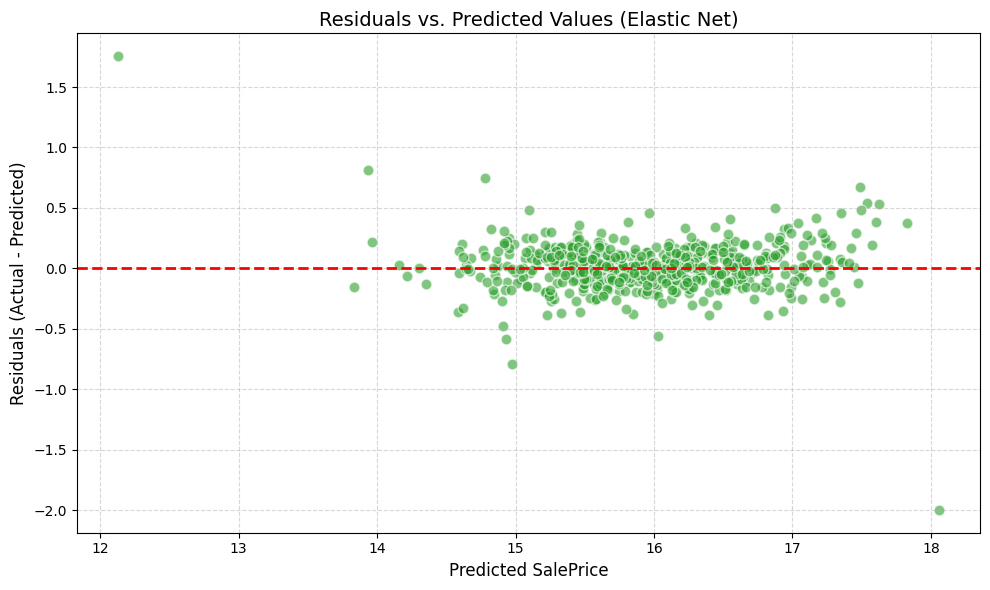

In [358]:
residuals2 = y_test_bc - elastic_net_pred_transform2

plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred_transform2, residuals2, 
            alpha=0.6, 
            color='#2ca02c', 
            edgecolors='w', 
            s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [359]:
residuals2 = y_test_bc - elastic_net_pred_transform2

from sklearn.model_selection import LeaveOneOut, cross_val_predict

press_test_proxy = np.sum(residuals2**2)

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(elastic_net2, X_train_transformed, y_train_bc, cv=loo)
press_statistic = np.sum((y_train_bc - y_pred_loo)**2)

print(f"PRESS Statistic: {press_statistic}")

PRESS Statistic: 115.30200174289972


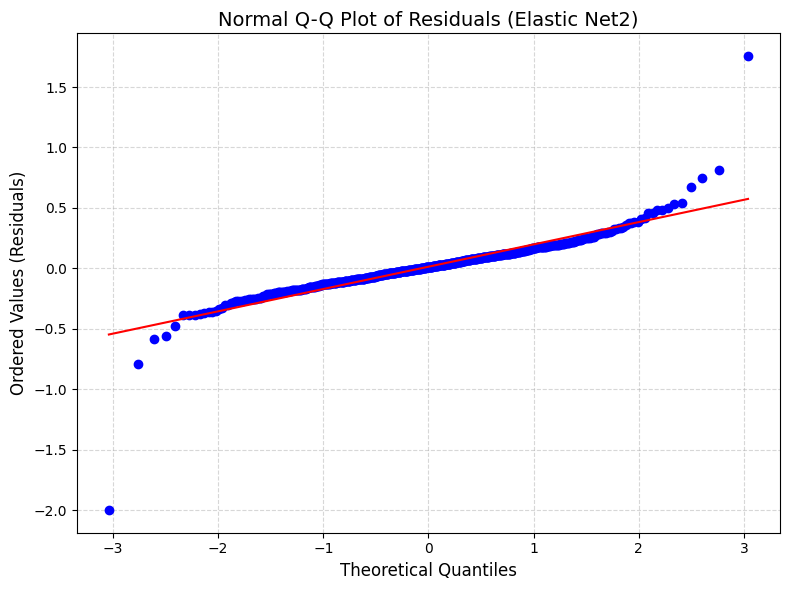

In [360]:
plt.figure(figsize=(8, 6))

stats.probplot(residuals2, dist="norm", plot=plt)

plt.title('Normal Q-Q Plot of Residuals (Elastic Net2)', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

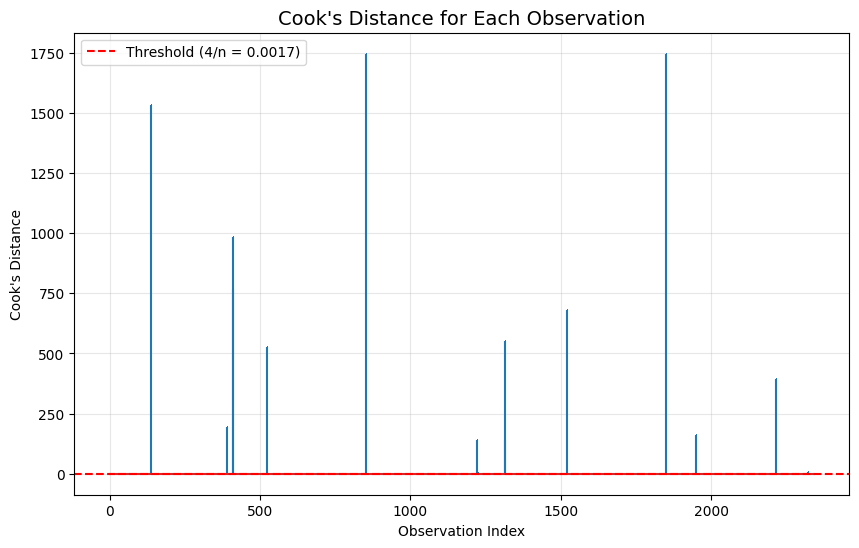

In [361]:
X_with_constant = sm.add_constant(X_train_transformed)

model = sm.OLS(y_train_bc, X_with_constant)
results_enet = model.fit_regularized(method='elastic_net', 
                                     alpha=en_cv.alpha_, 
                                     L1_wt=en_cv.l1_ratio_)

influence = sm.OLS(y_train_bc, X_with_constant).fit().get_influence()
(c, p) = influence.cooks_distance

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(c)), c, markerfmt=",")

threshold = 4 / len(c)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')

plt.title("Cook's Distance for Each Observation", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [362]:
skewnessy = stats.skew(y_train)
print(f"Skewness of SalePrice: {skewnessy:.4f}")

Skewness of SalePrice: 1.7495


In [363]:
y_train_bc2, lam = boxcox(y_train)
y_test_bc2 = boxcox(y_test, lmbda=lam)
print(f"Optimal Box-Cox Lambda: {lam:.4f}")

Optimal Box-Cox Lambda: 0.0443


In [364]:
skew_values = X_train.skew()

print("Skewness of all columns:")
print(skew_values)

highskew_values = skew_values[skew_values.abs() > 1]
print("\nColumns with high skewness (Abs Skew > 1):")
print(highskew_values)

Skewness of all columns:
MSSubClass                1.364770
LotFrontage               1.546519
LotArea                  13.743796
OverallQual               0.204464
OverallCond               0.595367
                           ...    
SaleCondition_AdjLand    17.040394
SaleCondition_Alloca     11.286850
SaleCondition_Family      7.366001
SaleCondition_Normal     -1.744059
SaleCondition_Partial     3.215252
Length: 283, dtype: float64

Columns with high skewness (Abs Skew > 1):
MSSubClass                1.364770
LotFrontage               1.546519
LotArea                  13.743796
MasVnrArea                2.462859
BsmtFinSF1                1.530008
                           ...    
SaleCondition_AdjLand    17.040394
SaleCondition_Alloca     11.286850
SaleCondition_Family      7.366001
SaleCondition_Normal     -1.744059
SaleCondition_Partial     3.215252
Length: 240, dtype: float64


In [365]:
from sklearn.preprocessing import PowerTransformer

# Get the list of skewed columns that ARE actually present in df
X_train_trans = X_train.copy()
X_test_trans = X_test.copy()

for col in highskew_values.index:
    pt = PowerTransformer(method='yeo-johnson')
    X_train_trans[col] = pt.fit_transform(X_train[[col]])[:, 0]
    X_test_trans[col] = pt.transform(X_test[[col]])[:, 0]

In [366]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_trans, y_train_bc)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net3 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net3.fit(X_train_trans, y_train_bc)

Optimal Alpha: 0.007390722033525776
Optimal L1 Ratio: 0.5


ElasticNet(alpha=np.float64(0.007390722033525776), l1_ratio=np.float64(0.5))

In [367]:
preds = elastic_net3.predict(X_test_trans)
rmse = np.sqrt(metrics.mean_squared_error(y_test_bc, preds))
r2 = metrics.r2_score(y_test_bc, preds)
print(f"Elastic Net with Yeo-Johnson Transformed Features | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Elastic Net with Yeo-Johnson Transformed Features | RMSE: $0.21 | R2: 0.9208


In [368]:
en_coefs = elastic_net3.coef_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': en_coefs
})

non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 283
Features kept by Elastic Net (non-zero): 128

--- Top 20 Most Important Features ---
             Feature  Coefficient
           @1stFlrSF     0.196912
         OverallQual     0.110967
         OverallCond     0.064191
             LotArea     0.061029
          BsmtFinSF1     0.059646
      Functional_Sal    -0.048498
          GarageCars     0.039182
SaleCondition_Normal     0.037226
          Fireplaces     0.035524
Neighborhood_NridgHt     0.034281
Neighborhood_Crawfor     0.034089
        BsmtFullBath     0.033528
     BsmtExposure_Gd     0.030501
        HeatingQC_TA    -0.027605
         BsmtQual_Ex     0.027503
    MSZoning_C (all)    -0.025602
     Condition1_Norm     0.024737
Neighborhood_Somerst     0.023823
 Exterior1st_BrkFace     0.022606
        CentralAir_Y     0.022199


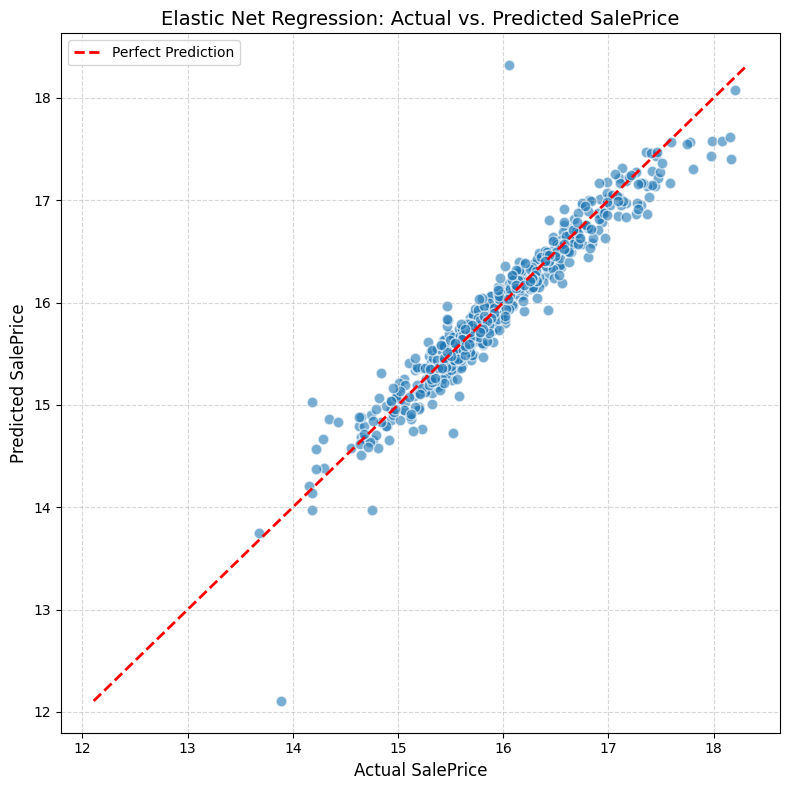

In [369]:
elastic_net_pred_transform3 = elastic_net3.predict(X_test_trans)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_bc2, elastic_net_pred_transform3, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test_bc2.min(), elastic_net_pred_transform3.min())
max_val = max(y_test_bc2.max(), elastic_net_pred_transform3.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

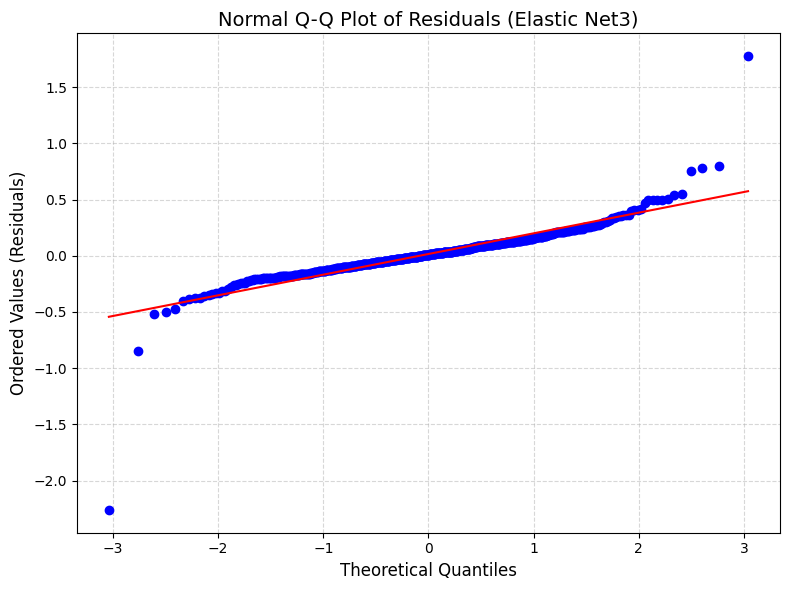

In [370]:
residuals3 = y_test_bc2 - elastic_net_pred_transform3

plt.figure(figsize=(8, 6))

stats.probplot(residuals3, dist="norm", plot=plt)

plt.title('Normal Q-Q Plot of Residuals (Elastic Net3)', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

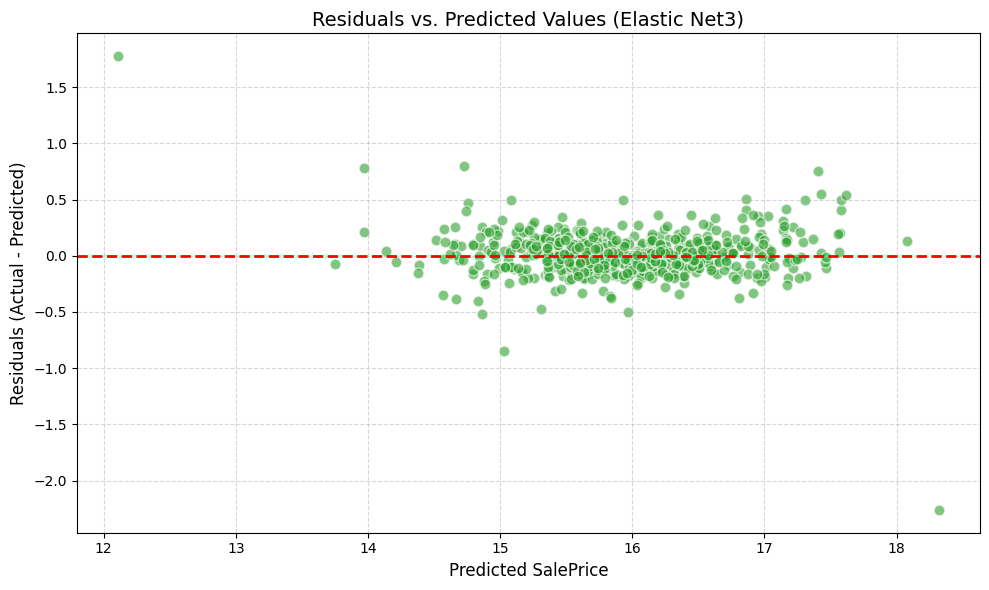

In [371]:
plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred_transform3, residuals3, 
            alpha=0.6, 
            color='#2ca02c', 
            edgecolors='w', 
            s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net3)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [372]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

press_test_proxy = np.sum(residuals3**2)

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(elastic_net3, X_train_trans, y_train_bc2, cv=loo)
press_statistic = np.sum((y_train_bc2 - y_pred_loo)**2)

print(f"PRESS Statistic: {press_statistic}")

PRESS Statistic: 111.71919867796215


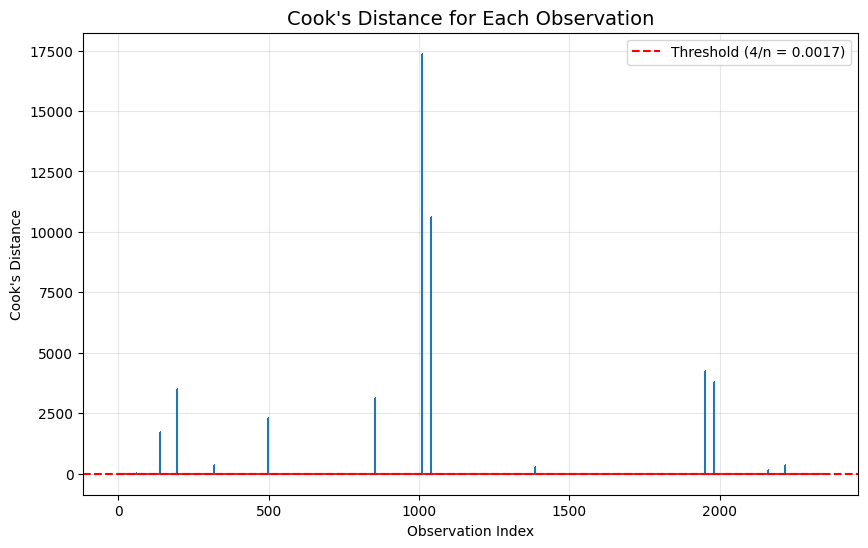

In [373]:
X_train_numeric = X_train_trans.apply(pd.to_numeric, errors='coerce').astype(float)
y_train_numeric = pd.to_numeric(y_train_bc2, errors='coerce').astype(float)


X_with_constant = sm.add_constant(X_train_numeric)
model = sm.OLS(y_train_numeric, X_with_constant)
results_enet = model.fit_regularized(method='elastic_net', 
                                     alpha=en_cv.alpha_, 
                                     L1_wt=en_cv.l1_ratio_)

influence = sm.OLS(y_train_numeric, X_with_constant).fit().get_influence()
(c, p) = influence.cooks_distance

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(c)), c, markerfmt=",")

threshold = 4 / len(c)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')

plt.title("Cook's Distance for Each Observation", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

variable selection approach

In [374]:
variances = df_encoded.var()
variance_df = pd.DataFrame(variances, columns=['Variance'])
variance_df = variance_df.sort_values(by='Variance', ascending=True)

print("--- Variables with the Lowest Variance ---")
print(variance_df.head(20))

threshold = 0.05
low_variance_cols = variance_df[variance_df['Variance'] < threshold].index.tolist()

print(f"\nColumns with variance below {threshold}:")
print(low_variance_cols)

--- Variables with the Lowest Variance ---
              Variance
Utilities     0.003070
Street        0.004080
PoolQC        0.017378
Condition2    0.043697
KitchenAbvGr  0.045829
Heating       0.060134
BsmtHalfBath  0.060149
LandSlope     0.061655
CentralAir    0.062441
Alley         0.067394
MiscFeature   0.133042
HalfBath      0.252636
BsmtFullBath  0.275436
PavedDrive    0.287713
RoofMatl      0.289671
FullBath      0.305743
Fireplaces    0.419802
ExterQual     0.492330
LandContour   0.494489
Foundation    0.527359

Columns with variance below 0.05:
['Utilities', 'Street', 'PoolQC', 'Condition2', 'KitchenAbvGr']


In [375]:
vars_to_check = num_cols

specific_correlations = df_encoded[vars_to_check].corr()[['SalePrice']]

correlations_threshold = 0.05
low_corr_cols = specific_correlations[abs(specific_correlations['SalePrice']) < correlations_threshold]

print("Correlation with SalePrice:")
print(specific_correlations.drop('SalePrice'))
print(f"\nColumns with low correlation to SalePrice (Abs Corr < {correlations_threshold}):")
print(low_corr_cols)

Correlation with SalePrice:
               SalePrice
Order          -0.031408
PID            -0.246521
MSSubClass     -0.085092
LotFrontage     0.357318
LotArea         0.266549
OverallQual     0.799262
OverallCond    -0.101697
YearBuilt       0.558426
YearRemodAdd    0.532974
MasVnrArea      0.508285
BsmtFinSF1      0.432914
BsmtFinSF2      0.005891
BsmtUnfSF       0.182855
TotalBsmtSF     0.632280
@1stFlrSF       0.621676
@2ndFlrSF       0.269373
LowQualFinSF   -0.037660
GrLivArea       0.706780
BsmtFullBath    0.276050
BsmtHalfBath   -0.035835
FullBath        0.545604
HalfBath        0.285056
BedroomAbvGr    0.143913
KitchenAbvGr   -0.119814
TotRmsAbvGrd    0.495474
Fireplaces      0.474558
GarageYrBlt     0.526965
GarageCars      0.647877
GarageArea      0.640401
WoodDeckSF      0.327143
OpenPorchSF     0.312951
EnclosedPorch  -0.128787
@3SsnPorch      0.032225
ScreenPorch     0.112151
PoolArea        0.068403
MiscVal        -0.015691
MoSold          0.035259
YrSold         -0.0305

In [376]:
from sklearn.feature_selection import f_classif
import pandas as pd

X_cat = df_encoded[cat_cols].fillna(0)
y_continuous = df_encoded['SalePrice']

f_scores, p_values = f_classif(X_cat, y_continuous)

anova_df = pd.DataFrame({
    'Feature': cat_cols,
    'F_Score': f_scores,
    'P_Value': p_values
})

anova_df = anova_df.sort_values(by='P_Value', ascending=False)

print("\n--- Categorical Variables with Weakest Relationship to SalePrice (ANOVA) ---")
print("(Higher P-Values = Means are similar across categories = Weak Predictor)")
print(anova_df.head(10))

p_val_threshold = 0.5
low_association = anova_df[anova_df['P_Value'] > p_val_threshold]['Feature'].tolist()

print(f"\nColumns to consider dropping (P-Value > {p_val_threshold}):")
print(low_association)




--- Categorical Variables with Weakest Relationship to SalePrice (ANOVA) ---
(Higher P-Values = Means are similar across categories = Weak Predictor)
         Feature   F_Score   P_Value
40   MiscFeature  0.695778  1.000000
25  BsmtFinType2  0.786592  0.999992
39         Fence  0.827582  0.999685
31    Functional  0.858053  0.997196
9     Condition1  0.929128  0.908715
2          Alley  0.940828  0.865590
19     ExterCond  0.973228  0.687868
6      LotConfig  0.974082  0.682195
11      BldgType  1.004069  0.468267
15   Exterior1st  1.022005  0.343263

Columns to consider dropping (P-Value > 0.5):
['MiscFeature', 'BsmtFinType2', 'Fence', 'Functional', 'Condition1', 'Alley', 'ExterCond', 'LotConfig']


In [379]:
cols_likely_to_drop = low_variance_cols + low_corr_cols.index.tolist() + low_association
print(cols_likely_to_drop)

['Utilities', 'Street', 'PoolQC', 'Condition2', 'KitchenAbvGr', 'Order', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', '@3SsnPorch', 'MiscVal', 'MoSold', 'YrSold', 'MiscFeature', 'BsmtFinType2', 'Fence', 'Functional', 'Condition1', 'Alley', 'ExterCond', 'LotConfig']


In [380]:
df_reduced = df_imputed.drop(columns=cols_likely_to_drop)
df_numeric_ready = pd.get_dummies(df_reduced, drop_first=True)
df_refined_selected = df_numeric_ready.copy()

In [381]:
y_selec = df_refined_selected['SalePrice'] 
X_selec = df_refined_selected.drop(columns=['SalePrice'])

X_train_selec, X_test_selec, y_train_selec, y_test_selec = train_test_split(
    X_selec, y_selec, test_size=0.2, random_state=42)


In [382]:
y_train_selec_bc, lam = boxcox(y_train_selec)
y_test_selec_bc = boxcox(y_test_selec, lmbda=lam)
print(f"Optimal Box-Cox Lambda: {lam:.4f}")

Optimal Box-Cox Lambda: 0.0443


In [383]:
X_train_selec_trans = pt.fit_transform(X_train_selec)
X_test_selec_trans = pt.transform(X_test_selec)

In [384]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_selec_trans, y_train_selec_bc)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net_selec1 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net_selec1.fit(X_train_selec_trans, y_train_selec_bc)

Optimal Alpha: 0.011768119524349979
Optimal L1 Ratio: 0.5


ElasticNet(alpha=np.float64(0.011768119524349979), l1_ratio=np.float64(0.5))

In [385]:
preds = elastic_net_selec1.predict(X_test_selec_trans)
rmse = np.sqrt(metrics.mean_squared_error(y_test_selec_bc, preds))
r2 = metrics.r2_score(y_test_selec_bc, preds)
print(f"Elastic Net with Yeo-Johnson Transformed Features | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Elastic Net with Yeo-Johnson Transformed Features | RMSE: $0.19 | R2: 0.9298


In [387]:
en_coefs = elastic_net_selec1.coef_

feature_importance = pd.DataFrame({
    'Feature': X_selec.columns,
    'Coefficient': en_coefs
})

non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 283
Features kept by Elastic Net (non-zero): 92

--- Top 20 Most Important Features ---
             Feature  Coefficient
           GrLivArea     0.196473
         OverallQual     0.147352
           YearBuilt     0.093959
         OverallCond     0.078458
             LotArea     0.057817
          GarageCars     0.050453
          BsmtFinSF1     0.048029
Neighborhood_NridgHt     0.034915
         TotalBsmtSF     0.031289
         BsmtQual_Ex     0.030293
Neighborhood_Crawfor     0.029223
SaleCondition_Normal     0.029106
Neighborhood_NoRidge     0.029096
     BsmtExposure_Gd     0.028505
        CentralAir_Y     0.026657
        HeatingQC_Po    -0.026045
          Fireplaces     0.026027
         MSZoning_RM    -0.025467
    MSZoning_C (all)    -0.023573
           @1stFlrSF     0.021943


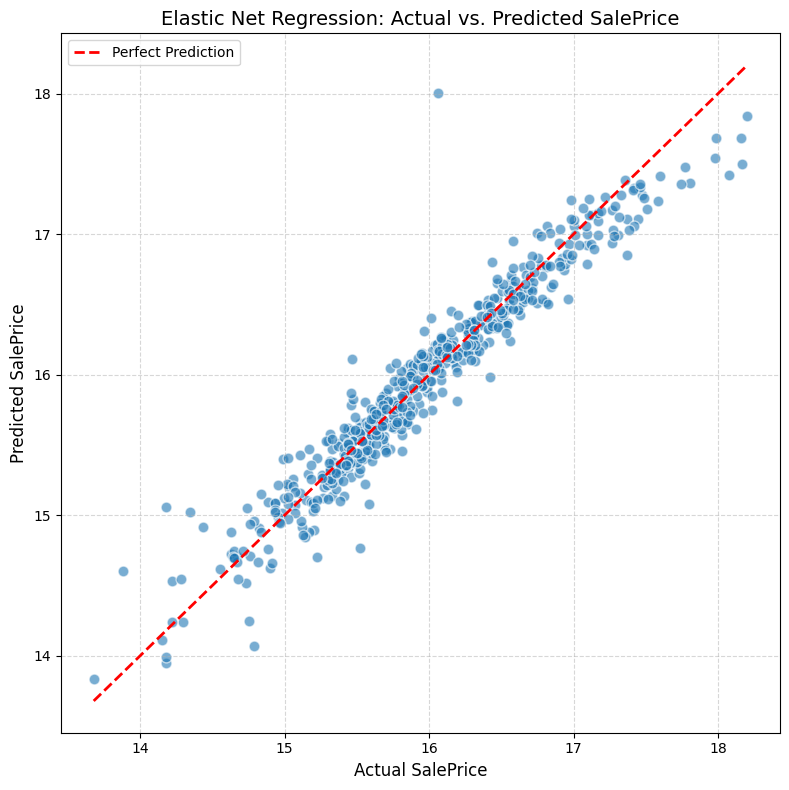

In [388]:
elastic_net_pred_selec = elastic_net_selec1.predict(X_test_selec_trans)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_selec_bc, elastic_net_pred_selec, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test_selec_bc.min(), elastic_net_pred_selec.min())
max_val = max(y_test_selec_bc.max(), elastic_net_pred_selec.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

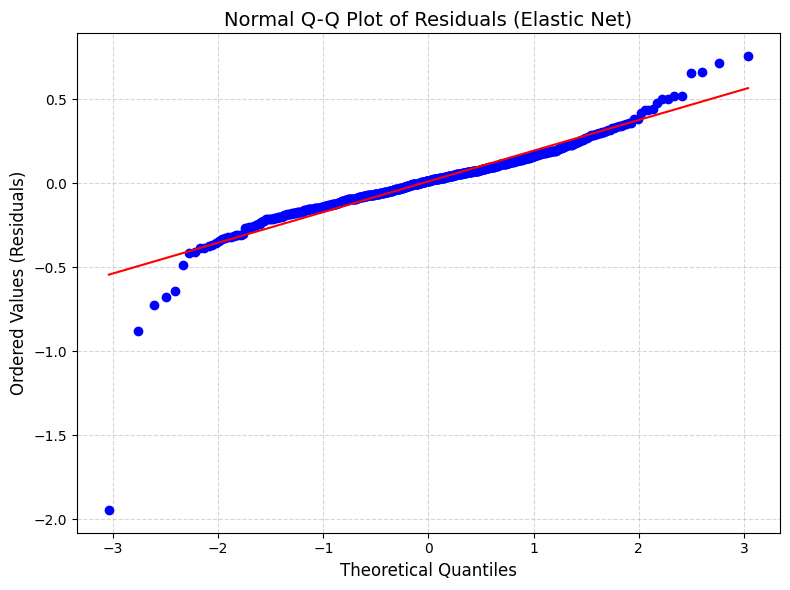

In [389]:
residuals_selec = y_test_selec_bc - elastic_net_pred_selec

plt.figure(figsize=(8, 6))

stats.probplot(residuals_selec, dist="norm", plot=plt)

plt.title('Normal Q-Q Plot of Residuals (Elastic Net)', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

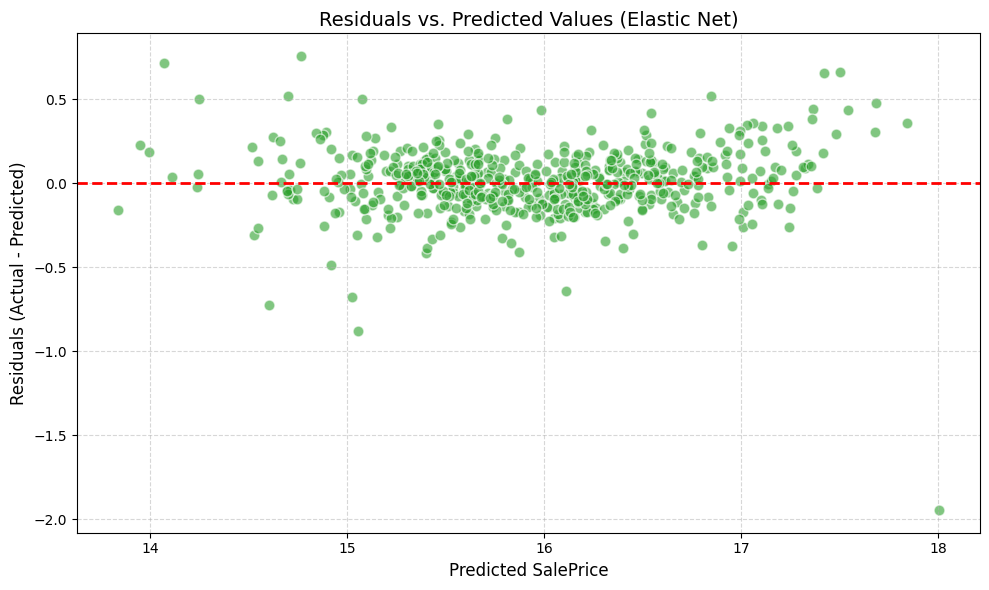

In [390]:
plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred_selec, residuals_selec, 
            alpha=0.6, 
            color='#2ca02c', 
            edgecolors='w', 
            s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [391]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

press_test_proxy = np.sum(residuals_selec**2)

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(elastic_net_selec1, X_train_selec_trans, y_train_selec_bc, cv=loo)
press_statistic = np.sum((y_train_selec_bc - y_pred_loo)**2)

print(f"PRESS Statistic: {press_statistic}")

PRESS Statistic: 117.34856373639673


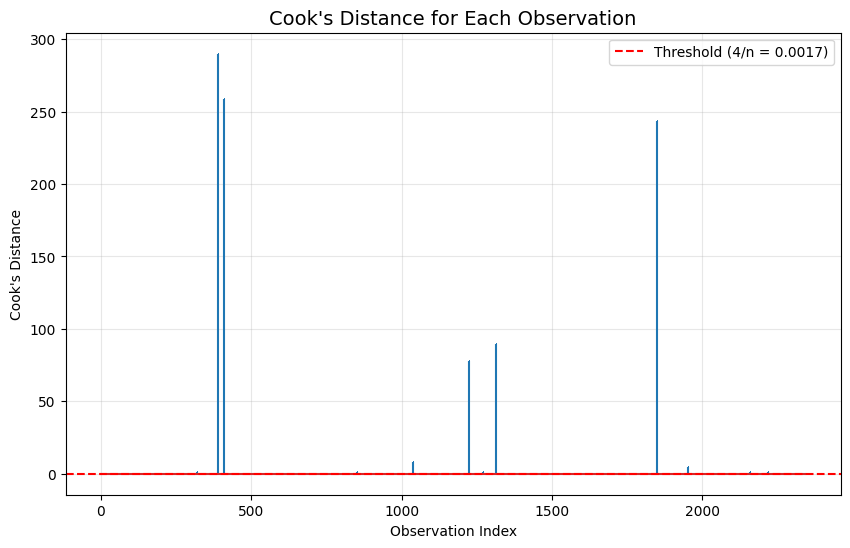

In [393]:
X_with_constant = sm.add_constant(X_train_selec_trans)
model = sm.OLS(y_train_selec_bc, X_with_constant)
results_enet = model.fit_regularized(method='elastic_net', 
                                     alpha=en_cv.alpha_, 
                                     L1_wt=en_cv.l1_ratio_)

influence = sm.OLS(y_train_selec_bc, X_with_constant).fit().get_influence()
(c, p) = influence.cooks_distance

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(c)), c, markerfmt=",")

threshold = 4 / len(c)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')

plt.title("Cook's Distance for Each Observation", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

transform only skewness greater>1

In [394]:
skew_values = X_train_selec.skew()

print("Skewness of all columns:")
print(skew_values)

highskew_values = skew_values[skew_values.abs() > 1]
print("\nColumns with high skewness (Abs Skew > 1):")
print(highskew_values)

Skewness of all columns:
PID                       0.057310
MSSubClass                1.364770
LotFrontage               1.546519
LotArea                  13.743796
OverallQual               0.204464
                           ...    
SaleCondition_AdjLand    17.040394
SaleCondition_Alloca     11.286850
SaleCondition_Family      7.366001
SaleCondition_Normal     -1.744059
SaleCondition_Partial     3.215252
Length: 223, dtype: float64

Columns with high skewness (Abs Skew > 1):
MSSubClass                1.364770
LotFrontage               1.546519
LotArea                  13.743796
MasVnrArea                2.462859
BsmtFinSF1                1.530008
                           ...    
SaleCondition_AdjLand    17.040394
SaleCondition_Alloca     11.286850
SaleCondition_Family      7.366001
SaleCondition_Normal     -1.744059
SaleCondition_Partial     3.215252
Length: 182, dtype: float64


In [400]:
from sklearn.preprocessing import PowerTransformer

# Get the list of skewed columns that ARE actually present in df
X_train_selec_trans2 = X_train_selec.copy()
X_test_selec_trans2 = X_test_selec.copy()

for col in highskew_values.index:
    pt = PowerTransformer(method='yeo-johnson')
    X_train_selec_trans2[col] = pt.fit_transform(X_train_selec[[col]])[:, 0]
    X_test_selec_trans2[col] = pt.transform(X_test_selec[[col]])[:, 0]

In [401]:
en_cv = ElasticNetCV(alphas=alphas, 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_selec_trans2, y_train_selec_bc)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net_selec2 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net_selec2.fit(X_train_selec_trans2, y_train_selec_bc)

Optimal Alpha: 0.04229242874389499
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.04229242874389499), l1_ratio=np.float64(0.1))

In [402]:
preds = elastic_net_selec2.predict(X_test_selec_trans2)
rmse = np.sqrt(metrics.mean_squared_error(y_test_selec_bc, preds))
r2 = metrics.r2_score(y_test_selec_bc, preds)
print(f"Elastic Net with Yeo-Johnson Transformed Features | RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Elastic Net with Yeo-Johnson Transformed Features | RMSE: $0.20 | R2: 0.9284


In [403]:
en_coefs = elastic_net_selec2.coef_

feature_importance = pd.DataFrame({
    'Feature': X_selec.columns,
    'Coefficient': en_coefs
})

non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

non_zero_features['Abs_Coefficient'] = non_zero_features['Coefficient'].abs()
top_features = non_zero_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(f"Total features originally: {len(X.columns)}")
print(f"Features kept by Elastic Net (non-zero): {len(non_zero_features)}")
print("\n--- Top 20 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Total features originally: 283
Features kept by Elastic Net (non-zero): 110

--- Top 20 Most Important Features ---
             Feature  Coefficient
         OverallQual     0.109743
           @1stFlrSF     0.106498
           GrLivArea     0.087871
         OverallCond     0.067792
             LotArea     0.051322
         TotalBsmtSF     0.046952
          BsmtFinSF1     0.041467
Neighborhood_NridgHt     0.038362
          GarageCars     0.033628
SaleCondition_Normal     0.033322
Neighborhood_Crawfor     0.032203
     BsmtExposure_Gd     0.029898
         BsmtQual_Ex     0.026433
        HeatingQC_Po    -0.025224
        CentralAir_Y     0.024426
          Fireplaces     0.024319
Neighborhood_NoRidge     0.023991
    MSZoning_C (all)    -0.023141
Neighborhood_StoneBr     0.022398
        BsmtFullBath     0.021703


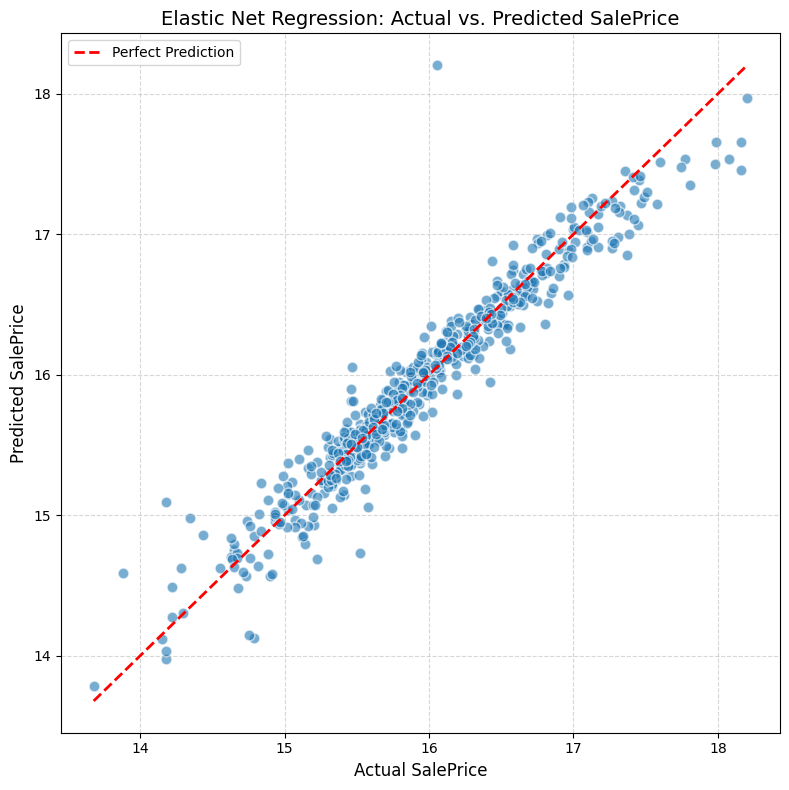

In [404]:
elastic_net_pred_selec_trans = elastic_net_selec2.predict(X_test_selec_trans2)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_selec_bc, elastic_net_pred_selec_trans, alpha=0.6, color='#1f77b4', edgecolors='w', s=60)

min_val = min(y_test_selec_bc.min(), elastic_net_pred_selec_trans.min())
max_val = max(y_test_selec_bc.max(), elastic_net_pred_selec_trans.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Elastic Net Regression: Actual vs. Predicted SalePrice', fontsize=14)
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

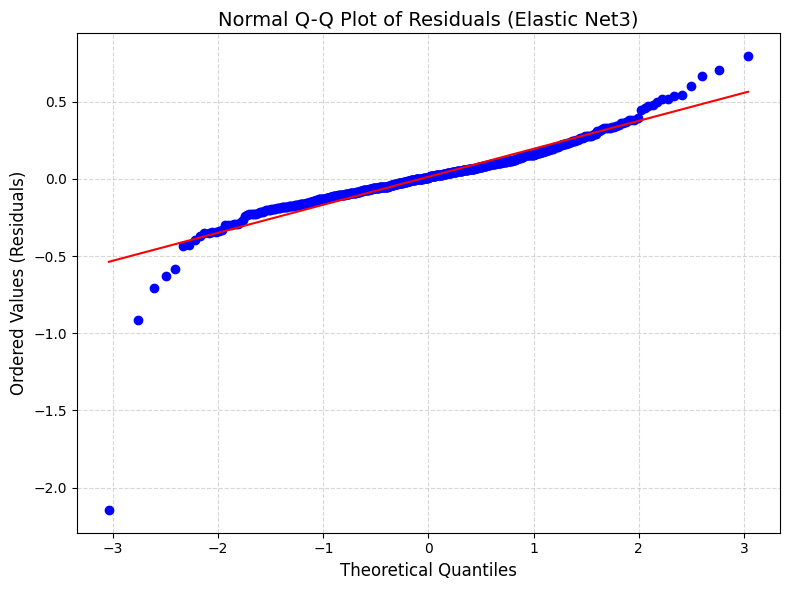

In [406]:
residuals_selec2 = y_test_selec_bc - elastic_net_pred_selec_trans

plt.figure(figsize=(8, 6))

stats.probplot(residuals_selec2, dist="norm", plot=plt)

plt.title('Normal Q-Q Plot of Residuals (Elastic Net3)', fontsize=14)
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values (Residuals)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

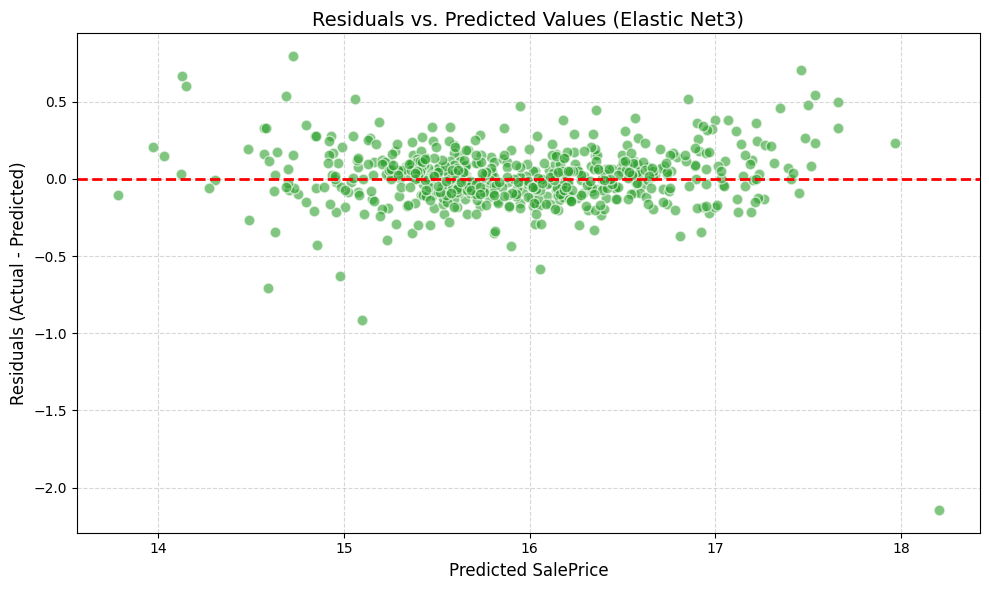

In [407]:
plt.figure(figsize=(10, 6))

plt.scatter(elastic_net_pred_selec_trans, residuals_selec2, 
            alpha=0.6, 
            color='#2ca02c', 
            edgecolors='w', 
            s=60)

plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.title('Residuals vs. Predicted Values (Elastic Net3)', fontsize=14)
plt.xlabel('Predicted SalePrice', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [409]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

press_test_proxy = np.sum(residuals_selec2**2)

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(elastic_net_selec2, X_train_selec_trans2, y_train_selec_bc, cv=loo)
press_statistic = np.sum((y_train_selec_bc - y_pred_loo)**2)

print(f"PRESS Statistic: {press_statistic}")

PRESS Statistic: 119.46964813591723


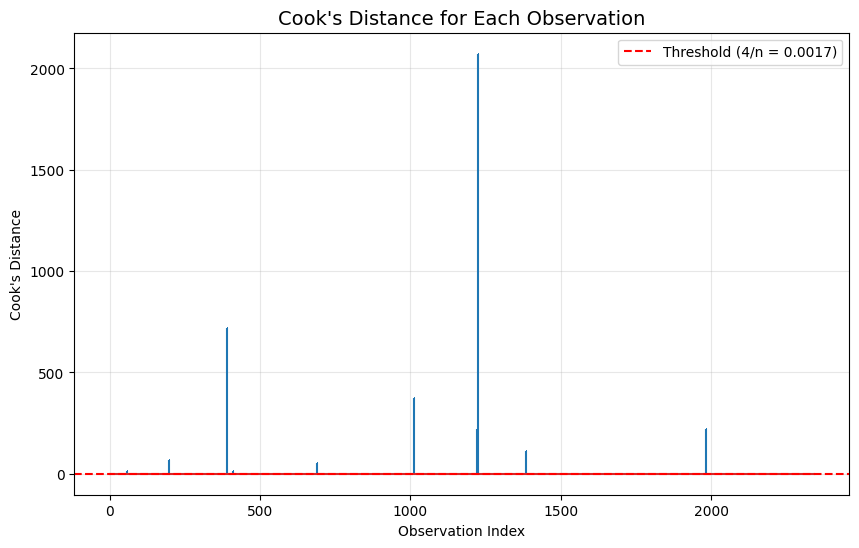

In [410]:
X_train_numeric = X_train_selec_trans2.apply(pd.to_numeric, errors='coerce').astype(float)
y_train_numeric = pd.to_numeric(y_train_selec_bc, errors='coerce').astype(float)


X_with_constant = sm.add_constant(X_train_numeric)
model = sm.OLS(y_train_numeric, X_with_constant)
results_enet = model.fit_regularized(method='elastic_net', 
                                     alpha=en_cv.alpha_, 
                                     L1_wt=en_cv.l1_ratio_)

influence = sm.OLS(y_train_numeric, X_with_constant).fit().get_influence()
(c, p) = influence.cooks_distance

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(c)), c, markerfmt=",")

threshold = 4 / len(c)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')

plt.title("Cook's Distance for Each Observation", fontsize=14)
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()